In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def plot_confusion_matrix(cm, labels, title, filename):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


def evaluate_classification(y_true, y_pred, y_proba=None, pos_label=1):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label)
    rec = recall_score(y_true, y_pred, pos_label=pos_label)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC  : {roc_auc:.4f}")
    else:
        roc_auc = None

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc
    }


def plot_roc_curve_sklearn(y_true, y_score, title, filename):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_decision_boundary_2d(model, X, y, title, filename, plot_support_vectors=True):
    """
    2D 데이터용 SVM 결정 경계 시각화 함수
    X: (n_samples, 2)
    y: (n_samples,)
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # decision_function 값 또는 예측 확률 사용 (여기선 decision_function)
    Z = model.decision_function(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    # 배경: decision_function 값
    contour = plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.7)
    plt.colorbar(contour, label='decision_function(x)')

    # 결정 경계(0) + 마진(+1, -1)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='k', linestyles='--', linewidths=1.5)

    # 데이터 포인트
    scatter = plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap='coolwarm',
        edgecolors='black',
        s=40
    )

    # Support Vector 표시
    if plot_support_vectors and hasattr(model, 'support_vectors_'):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=120,
            facecolors='none',
            edgecolors='yellow',
            linewidths=2,
            label='Support Vectors'
        )

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)

    handles, _ = scatter.legend_elements()
    labels = ['Class 0', 'Class 1']
    legend_handles = handles
    legend_labels = labels

    if plot_support_vectors and hasattr(model, 'support_vectors_'):
        legend_handles = legend_handles + [plt.Line2D([0], [0], marker='o', color='w',
                                                      markerfacecolor='none',
                                                      markeredgecolor='yellow',
                                                      markersize=10,
                                                      linestyle='')]
        legend_labels = legend_labels + ['Support Vectors']

    plt.legend(legend_handles, legend_labels, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

1. 토이 데이터 (make_moons) - Linear SVM vs RBF SVM


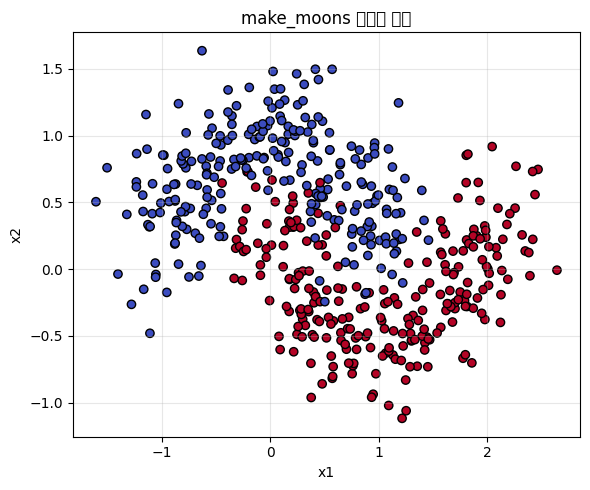

Train shape: (350, 2), Test shape: (150, 2)

[1-1] Linear SVM (kernel='linear')
Linear SVM 성능:
Accuracy : 0.8400
Precision: 0.8592
Recall   : 0.8133
F1-Score : 0.8356

Support Vector 개수 (Linear): 113


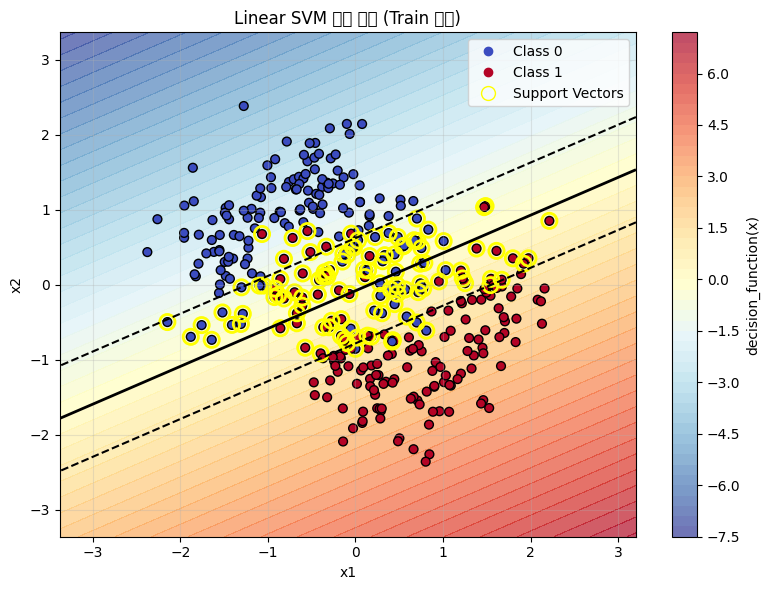


[1-2] RBF SVM (kernel='rbf')
RBF SVM 성능:
Accuracy : 0.9467
Precision: 0.9718
Recall   : 0.9200
F1-Score : 0.9452

Support Vector 개수 (RBF): 99


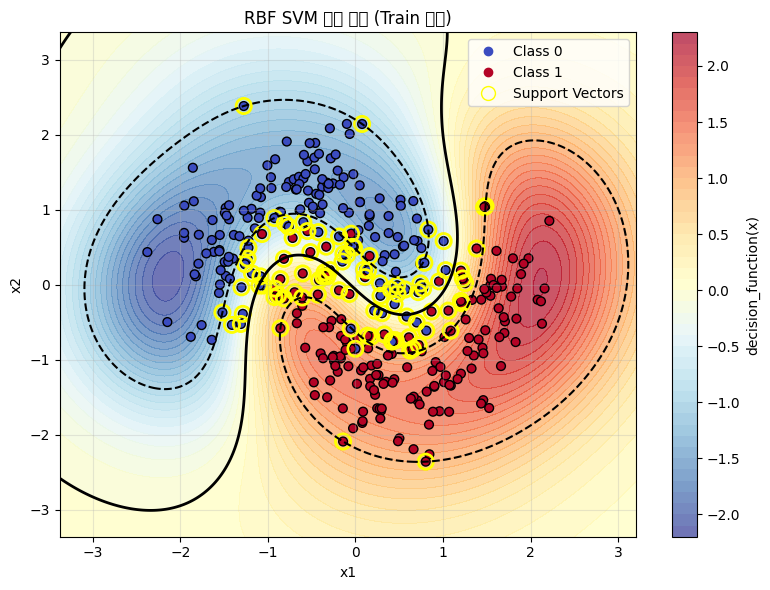

In [ ]:
print("=" * 70)
print("1. 토이 데이터 (make_moons) - Linear SVM vs RBF SVM")
print("=" * 70)

X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolor='k')
plt.title("make_moons 데이터 분포")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moons_raw.png', dpi=300, bbox_inches='tight')
plt.show()

# Train/Test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons,
    test_size=0.3,
    random_state=42,
    stratify=y_moons
)

print(f"Train shape: {X_train_m.shape}, Test shape: {X_test_m.shape}")

# 스케일링
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# 1-1. Linear SVM
print("\n[1-1] Linear SVM (kernel='linear')")
linear_svm = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)
linear_svm.fit(X_train_m_scaled, y_train_m)

y_pred_lin = linear_svm.predict(X_test_m_scaled)
print("Linear SVM 성능:")
metrics_lin = evaluate_classification(y_test_m, y_pred_lin)

print("\nSupport Vector 개수 (Linear):", linear_svm.support_vectors_.shape[0])

plot_decision_boundary_2d(
    linear_svm,
    X_train_m_scaled,
    y_train_m,
    "Linear SVM 결정 경계 (Train 기준)",
    "moons_linear_decision_boundary.png"
)

# 1-2. RBF SVM
print("\n[1-2] RBF SVM (kernel='rbf')")
rbf_svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)
rbf_svm.fit(X_train_m_scaled, y_train_m)

y_pred_rbf = rbf_svm.predict(X_test_m_scaled)
print("RBF SVM 성능:")
metrics_rbf = evaluate_classification(y_test_m, y_pred_rbf)

print("\nSupport Vector 개수 (RBF):", rbf_svm.support_vectors_.shape[0])

plot_decision_boundary_2d(
    rbf_svm,
    X_train_m_scaled,
    y_train_m,
    "RBF SVM 결정 경계 (Train 기준)",
    "moons_rbf_decision_boundary.png"
)


2. C, γ 변화에 따른 결정 경계 비교 (RBF SVM)


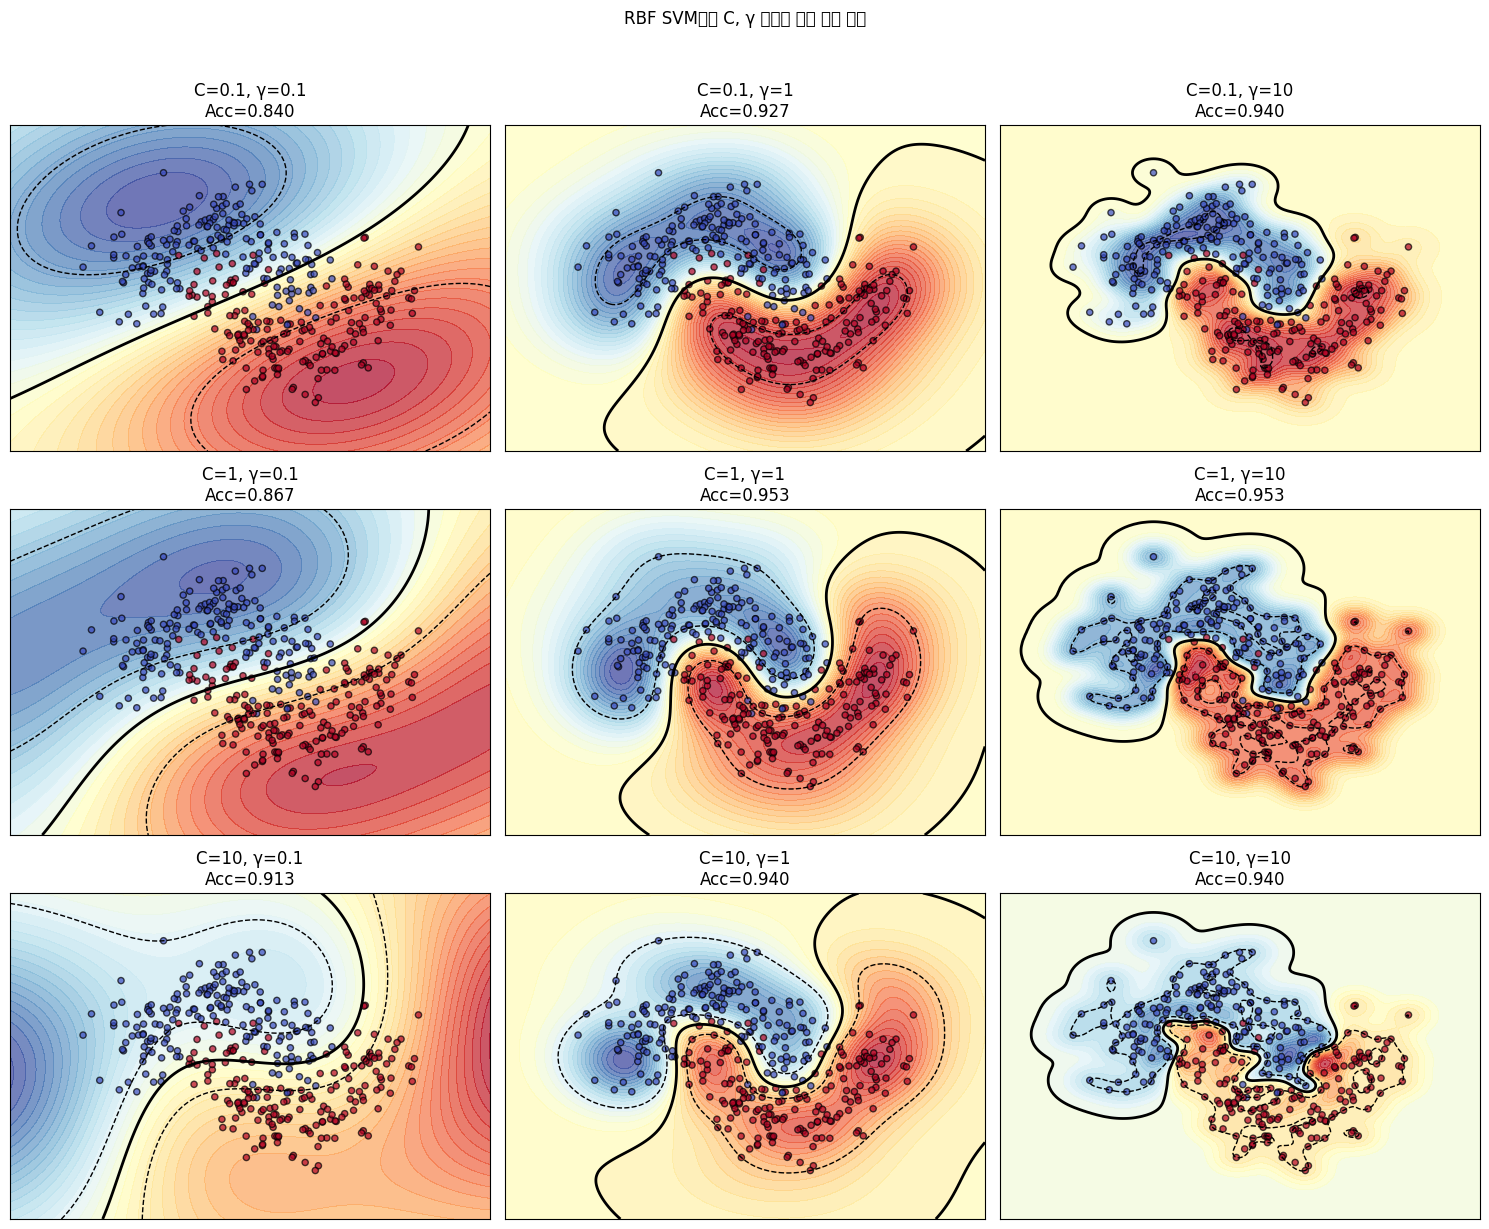


해석 가이드:
- C ↑ : 오분류를 줄이기 위해 더 복잡한 경계 → 과적합 위험 증가
- γ ↑ : 영향 범위가 좁아지며, 데이터 포인트 근처에서만 크게 휘어짐 → 너무 크면 노이즈까지 따라감


In [ ]:
print("\n" + "=" * 70)
print("2. C, γ 변화에 따른 결정 경계 비교 (RBF SVM)")
print("=" * 70)

C_list = [0.1, 1, 10]
gamma_list = [0.1, 1, 10]  # 예시 값 (스케일 기준)

X_plot = X_train_m_scaled
y_plot = y_train_m

h = 0.03
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

fig, axes = plt.subplots(len(C_list), len(gamma_list), figsize=(15, 12))
axes = axes.ravel()

idx = 0
for C in C_list:
    for gamma in gamma_list:
        model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            random_state=42
        )
        model.fit(X_train_m_scaled, y_train_m)

        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax = axes[idx]
        idx += 1

        contour = ax.contourf(xx, yy, Z, levels=40, cmap='RdYlBu_r', alpha=0.7)
        ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
        ax.contour(xx, yy, Z, levels=[-1, 1], colors='k', linestyles='--', linewidths=1)

        ax.scatter(
            X_plot[:, 0], X_plot[:, 1],
            c=y_plot,
            cmap='coolwarm',
            edgecolors='black',
            s=20,
            alpha=0.7
        )

        # 성능 (test 기준)
        y_pred_cg = model.predict(X_test_m_scaled)
        acc_cg = accuracy_score(y_test_m, y_pred_cg)

        ax.set_title(f"C={C}, γ={gamma}\nAcc={acc_cg:.3f}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle(
    "RBF SVM에서 C, γ 변화에 따른 결정 경계",
    y=1.02
)
plt.tight_layout()
plt.savefig("moons_C_gamma_grid.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n해석 가이드:")
print("- C ↑ : 오분류를 줄이기 위해 더 복잡한 경계 → 과적합 위험 증가")
print("- γ ↑ : 영향 범위가 좁아지며, 데이터 포인트 근처에서만 크게 휘어짐 → 너무 크면 노이즈까지 따라감")


3. Breast Cancer 데이터셋으로 SVM 분류
데이터 shape: (569, 30)
타겟 이름: ['malignant' 'benign']
타겟 분포: {1: 357, 0: 212}

[3-1] 기본 RBF SVM 모델 (GridSearch 전)
기본 모델 성능:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9950

Confusion Matrix (수치):
[[41  1]
 [ 1 71]]


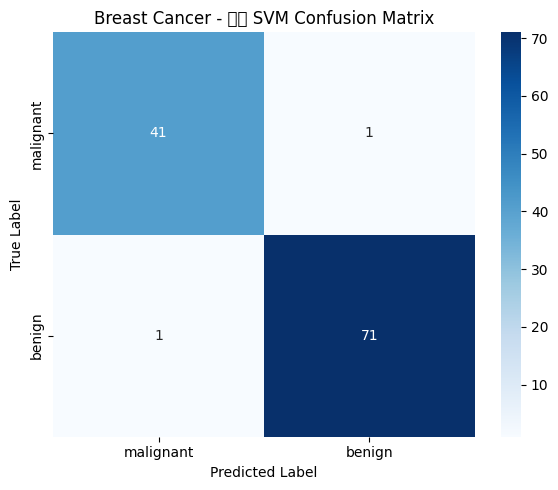

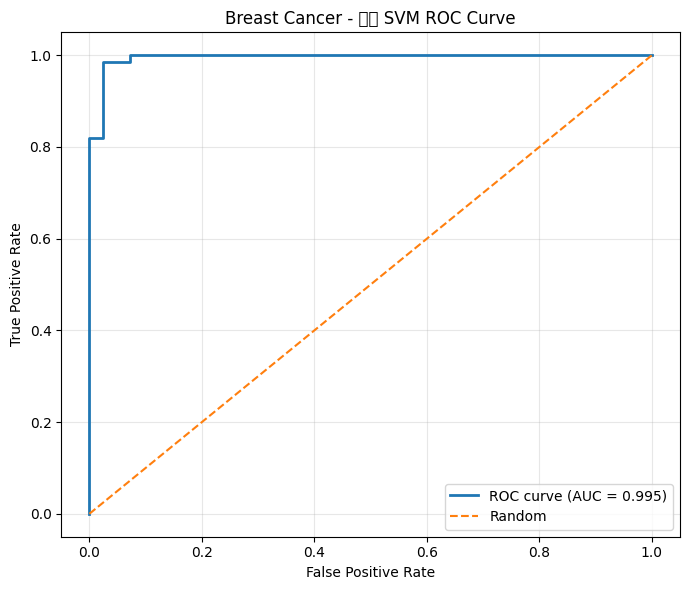

In [ ]:
print("\n" + "=" * 70)
print("3. Breast Cancer 데이터셋으로 SVM 분류")
print("=" * 70)

data = load_breast_cancer()
X_bc = data.data
y_bc = data.target
feature_names_bc = data.feature_names
target_names_bc = data.target_names

print("데이터 shape:", X_bc.shape)
print("타겟 이름:", target_names_bc)
print("타겟 분포:", pd.Series(y_bc).value_counts().to_dict())

# Train/Test split
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc,
    test_size=0.2,
    random_state=42,
    stratify=y_bc
)

# 스케일링
scaler_bc = StandardScaler()
X_train_bc_scaled = scaler_bc.fit_transform(X_train_bc)
X_test_bc_scaled = scaler_bc.transform(X_test_bc)

# 3-1. 기본 RBF SVM 모델
print("\n[3-1] 기본 RBF SVM 모델 (GridSearch 전)")
base_svm_bc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,      # ROC, 확률 위해 True
    random_state=42
)
base_svm_bc.fit(X_train_bc_scaled, y_train_bc)

y_pred_base_bc = base_svm_bc.predict(X_test_bc_scaled)
y_proba_base_bc = base_svm_bc.predict_proba(X_test_bc_scaled)[:, 1]

print("기본 모델 성능:")
metrics_base_bc = evaluate_classification(y_test_bc, y_pred_base_bc, y_proba_base_bc, pos_label=1)

cm_base_bc = confusion_matrix(y_test_bc, y_pred_base_bc)
print("\nConfusion Matrix (수치):")
print(cm_base_bc)

plot_confusion_matrix(
    cm_base_bc,
    labels=[f"{target_names_bc[0]}", f"{target_names_bc[1]}"],
    title="Breast Cancer - 기본 SVM Confusion Matrix",
    filename="bc_confusion_matrix_base.png"
)

plot_roc_curve_sklearn(
    y_test_bc,
    y_proba_base_bc,
    "Breast Cancer - 기본 SVM ROC Curve",
    "bc_roc_base.png"
)


4. GridSearchCV로 RBF SVM 하이퍼파라미터 튜닝
GridSearch 파라미터:
{'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf']}

GridSearchCV 실행 중...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

최적 하이퍼파라미터:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
최적 CV ROC-AUC: 0.9954

[기본 모델 vs 최적 모델 성능 비교]
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9977

기본 vs 최적 모델 성능 비교표:
       지표    기본 모델    최적 모델   개선율(%)
 Accuracy 0.982456 0.982456 0.000000
Precision 0.986111 0.986111 0.000000
   Recall 0.986111 0.986111 0.000000
 F1-Score 0.986111 0.986111 0.000000
  ROC-AUC 0.995040 0.997685 0.265869

Confusion Matrix (최적 모델):
[[41  1]
 [ 1 71]]


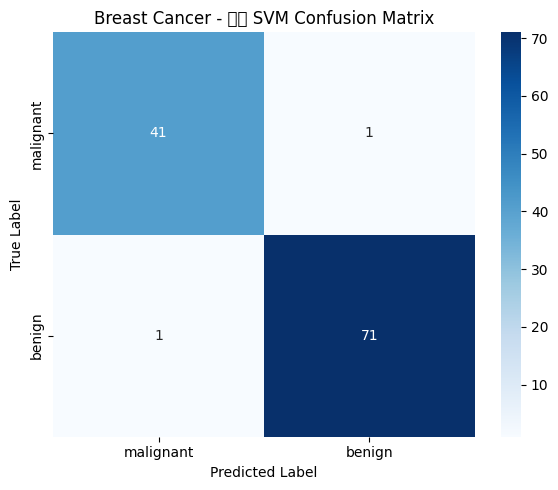

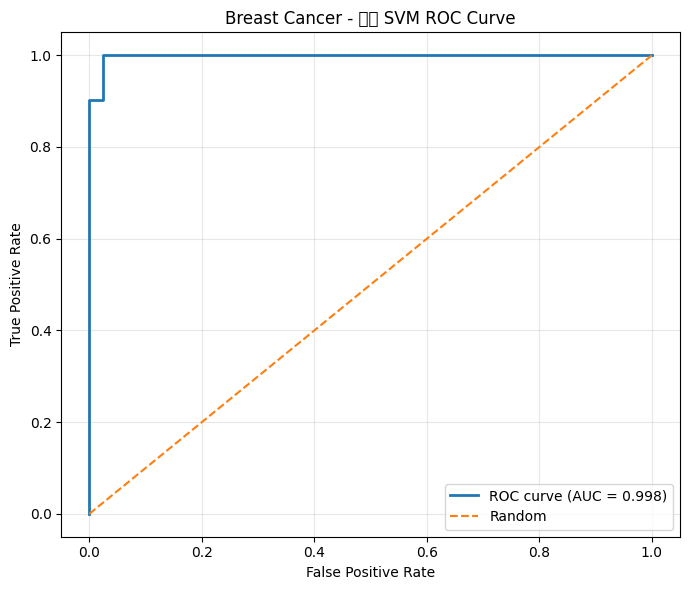


Classification Report (최적 모델):
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== SVM 분류 실습 전체 종료 ===


In [ ]:
# ------------------------------------------------------------
# 4. GridSearchCV로 C, γ 튜닝 + 최적 모델 비교
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("4. GridSearchCV로 RBF SVM 하이퍼파라미터 튜닝")
print("=" * 70)

param_grid_bc = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

print("GridSearch 파라미터:")
print(param_grid_bc)

grid_search_bc = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid_bc,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nGridSearchCV 실행 중...")
grid_search_bc.fit(X_train_bc_scaled, y_train_bc)

print("\n최적 하이퍼파라미터:")
print(grid_search_bc.best_params_)
print(f"최적 CV ROC-AUC: {grid_search_bc.best_score_:.4f}")

best_svm_bc = grid_search_bc.best_estimator_

# 최적 모델 평가
y_pred_best_bc = best_svm_bc.predict(X_test_bc_scaled)
y_proba_best_bc = best_svm_bc.predict_proba(X_test_bc_scaled)[:, 1]

print("\n[기본 모델 vs 최적 모델 성능 비교]")
metrics_best_bc = evaluate_classification(y_test_bc, y_pred_best_bc, y_proba_best_bc, pos_label=1)

# 표 형태로 정리
comparison_df = pd.DataFrame({
    '지표': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    '기본 모델': [
        metrics_base_bc['accuracy'],
        metrics_base_bc['precision'],
        metrics_base_bc['recall'],
        metrics_base_bc['f1'],
        metrics_base_bc['roc_auc'],
    ],
    '최적 모델': [
        metrics_best_bc['accuracy'],
        metrics_best_bc['precision'],
        metrics_best_bc['recall'],
        metrics_best_bc['f1'],
        metrics_best_bc['roc_auc'],
    ]
})
comparison_df['개선율(%)'] = (
    (comparison_df['최적 모델'] - comparison_df['기본 모델'])
    / comparison_df['기본 모델'] * 100
)

print("\n기본 vs 최적 모델 성능 비교표:")
print(comparison_df.to_string(index=False))

# 최적 모델 Confusion Matrix & ROC
cm_best_bc = confusion_matrix(y_test_bc, y_pred_best_bc)
print("\nConfusion Matrix (최적 모델):")
print(cm_best_bc)

plot_confusion_matrix(
    cm_best_bc,
    labels=[f"{target_names_bc[0]}", f"{target_names_bc[1]}"],
    title="Breast Cancer - 최적 SVM Confusion Matrix",
    filename="bc_confusion_matrix_best.png"
)

plot_roc_curve_sklearn(
    y_test_bc,
    y_proba_best_bc,
    "Breast Cancer - 최적 SVM ROC Curve",
    "bc_roc_best.png"
)

print("\nClassification Report (최적 모델):")
print(classification_report(y_test_bc, y_pred_best_bc, target_names=target_names_bc))

print("\n=== SVM 분류 실습 전체 종료 ===")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ------------------------------------------------------------
# 공통 유틸 함수
# ------------------------------------------------------------
def evaluate_regression(y_true, y_pred, prefix=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    if prefix:
        print(f"[{prefix}]")

    print(f"MSE :  {mse:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE :  {mae:.4f}")
    print(f"R^2 :  {r2:.4f}")

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }


def plot_svr_1d(model, X_train, y_train, X_test=None, y_test=None,
                title="SVR 회귀 곡선", filename="svr_1d.png",
                x_min=None, x_max=None, eps_tube=True):
    """
    1D 데이터용 SVR 곡선 시각화
    - X: (n_samples, 1)
    - y: (n_samples,)
    """
    if x_min is None:
        x_min = X_train.min() - 0.5
    if x_max is None:
        x_max = X_train.max() + 0.5

    X_line = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    y_line_pred = model.predict(X_line)

    plt.figure(figsize=(8, 6))

    # Train 데이터
    plt.scatter(
        X_train, y_train,
        color='blue',
        label='Train 데이터',
        alpha=0.7,
        edgecolors='black'
    )

    # Test 데이터 (있으면)
    if X_test is not None and y_test is not None:
        plt.scatter(
            X_test, y_test,
            color='green',
            label='Test 데이터',
            alpha=0.7,
            edgecolors='black'
        )

    # 예측 곡선
    plt.plot(
        X_line, y_line_pred,
        color='red',
        linewidth=2,
        label='SVR 예측 곡선'
    )

    # ε-tube (옵션)
    if eps_tube and hasattr(model, "epsilon"):
        eps = model.epsilon
        plt.plot(
            X_line, y_line_pred + eps,
            color='orange',
            linestyle='--',
            linewidth=1.5,
            label=f'예측 + ε (ε={eps})'
        )
        plt.plot(
            X_line, y_line_pred - eps,
            color='orange',
            linestyle='--',
            linewidth=1.5,
            label=f'예측 - ε (ε={eps})'
        )

    plt.xlabel("X", fontsize=12)
    plt.ylabel("y", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

1. 1D 토이 데이터 (sin + noise) - SVR 기초


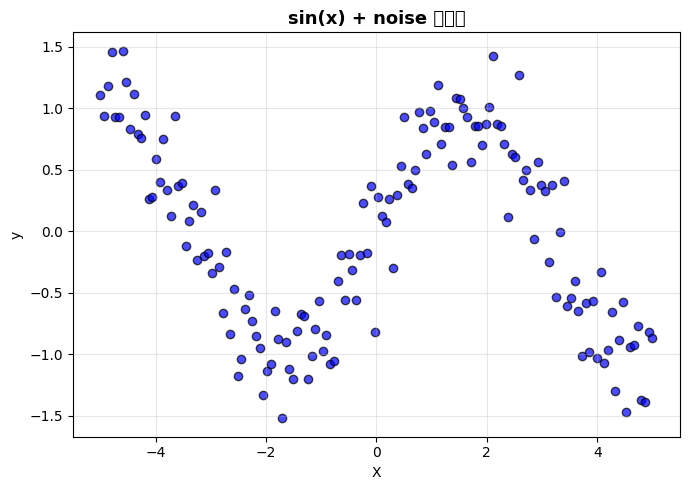

Train shape: (120, 1), Test shape: (30, 1)


In [ ]:
# ------------------------------------------------------------
# 1. 1D 토이 데이터 (sin + noise)로 SVR 직관 익히기
# ------------------------------------------------------------
print("=" * 70)
print("1. 1D 토이 데이터 (sin + noise) - SVR 기초")
print("=" * 70)

# 데이터 생성
np.random.seed(42)
n_samples = 150

X = np.linspace(-5, 5, n_samples)
y = np.sin(X) + 0.3 * np.random.randn(n_samples)  # 노이즈 추가

X = X.reshape(-1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', alpha=0.7, edgecolors='black')
plt.title("sin(x) + noise 데이터", fontsize=13, fontweight='bold')
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("svr_toy_raw.png", dpi=300, bbox_inches='tight')
plt.show()

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# 입력 X만 스케일링 (y는 그대로 사용해 직관 유지)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


[1-1] 기본 RBF SVR 모델 (kernel='rbf')

Train 성능:
[Train]
MSE :  0.0776
RMSE:  0.2785
MAE :  0.2208
R^2 :  0.8830

Test 성능:
[Test]
MSE :  0.0775
RMSE:  0.2784
MAE :  0.2232
R^2 :  0.8156


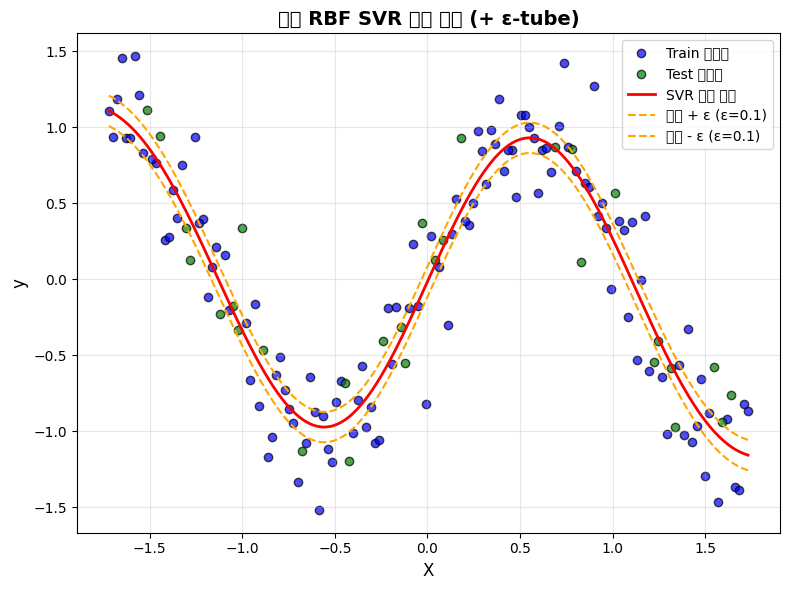

In [ ]:
# ------------------------------------------------------------
# 1-1. 기본 RBF SVR 모델 학습
# ------------------------------------------------------------
print("\n[1-1] 기본 RBF SVR 모델 (kernel='rbf')")
base_svr = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1,
    gamma='scale'
)
base_svr.fit(X_train_scaled, y_train)

# 예측 및 평가
y_pred_train = base_svr.predict(X_train_scaled)
y_pred_test = base_svr.predict(X_test_scaled)

print("\nTrain 성능:")
metrics_train = evaluate_regression(y_train, y_pred_train, prefix="Train")

print("\nTest 성능:")
metrics_test = evaluate_regression(y_test, y_pred_test, prefix="Test")

# 곡선 + ε-tube 시각화
plot_svr_1d(
    base_svr,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    title="기본 RBF SVR 예측 곡선 (+ ε-tube)",
    filename="svr_toy_base.png",
    x_min=X_train_scaled.min(),
    x_max=X_train_scaled.max(),
    eps_tube=True
)


1-2. C 값 변화에 따른 SVR 곡선 비교


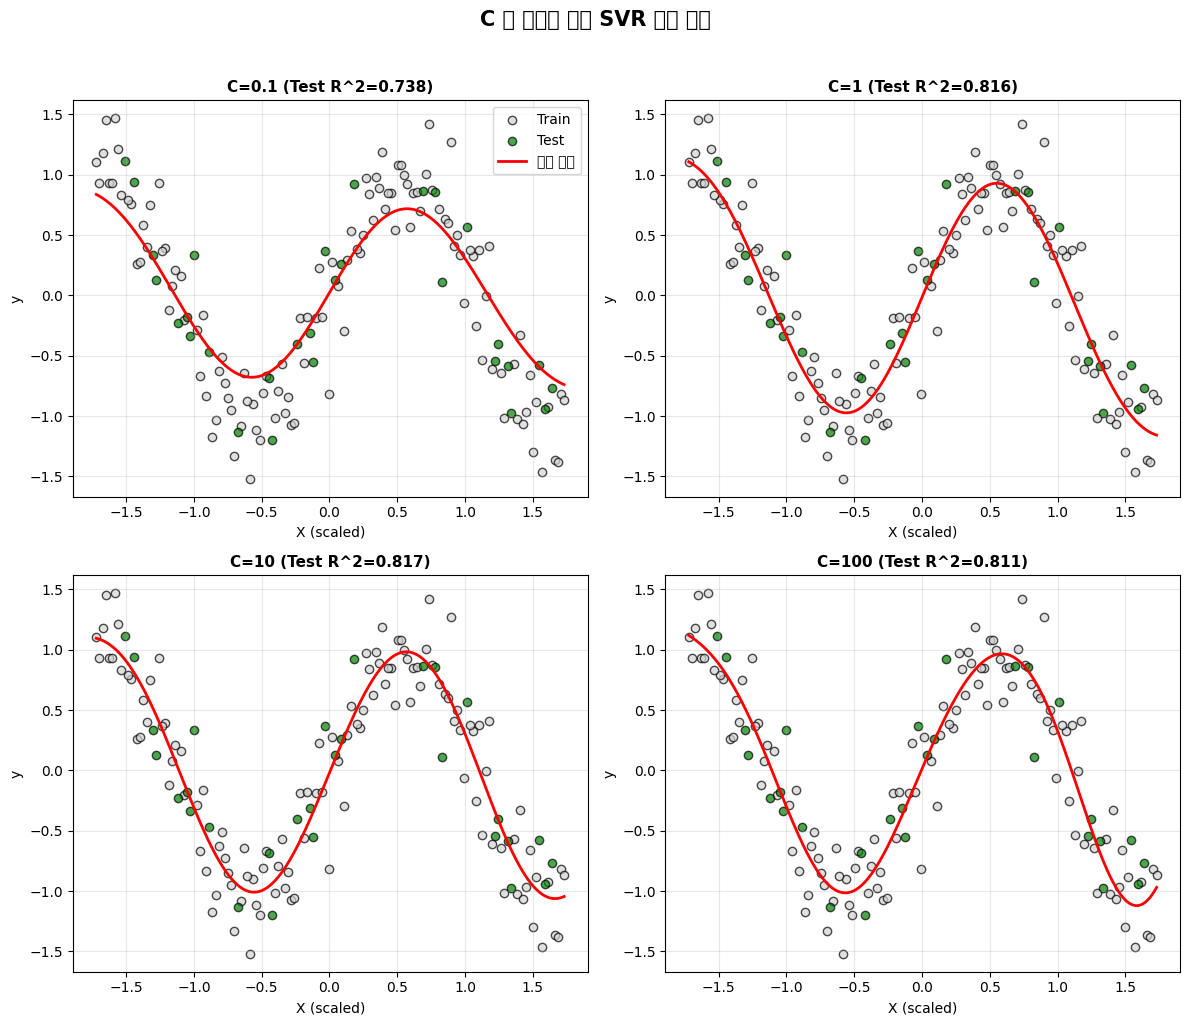


해석 가이드:
- C 작음: 오차를 더 허용 → 더 부드러운 곡선, underfitting 경향
- C 큼  : 오차를 최대한 줄이려 함 → 데이터/노이즈를 더 세게 따라감, overfitting 위험


In [ ]:
# ------------------------------------------------------------
# 1-2. C 변화에 따른 곡선 비교
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("1-2. C 값 변화에 따른 SVR 곡선 비교")
print("=" * 70)

C_list = [0.1, 1, 10, 100]
x_min, x_max = X_train_scaled.min(), X_train_scaled.max()
X_line = np.linspace(x_min, x_max, 500).reshape(-1, 1)

plt.figure(figsize=(12, 10))

for i, C_val in enumerate(C_list, start=1):
    svr_c = SVR(
        kernel='rbf',
        C=C_val,
        epsilon=0.1,
        gamma='scale'
    )
    svr_c.fit(X_train_scaled, y_train)
    y_line_pred_c = svr_c.predict(X_line)

    y_pred_test_c = svr_c.predict(X_test_scaled)
    r2_c = r2_score(y_test, y_pred_test_c)

    plt.subplot(2, 2, i)
    plt.scatter(X_train_scaled, y_train, color='lightgray', edgecolor='k', alpha=0.7, label='Train')
    plt.scatter(X_test_scaled, y_test, color='green', edgecolor='k', alpha=0.7, label='Test')
    plt.plot(X_line, y_line_pred_c, color='red', linewidth=2, label='예측 곡선')
    plt.title(f"C={C_val} (Test R^2={r2_c:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("X (scaled)")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend()

plt.suptitle("C 값 변화에 따른 SVR 예측 곡선", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("svr_toy_C_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n해석 가이드:")
print("- C 작음: 오차를 더 허용 → 더 부드러운 곡선, underfitting 경향")
print("- C 큼  : 오차를 최대한 줄이려 함 → 데이터/노이즈를 더 세게 따라감, overfitting 위험")



1-3. γ 값 변화에 따른 SVR 곡선 비교


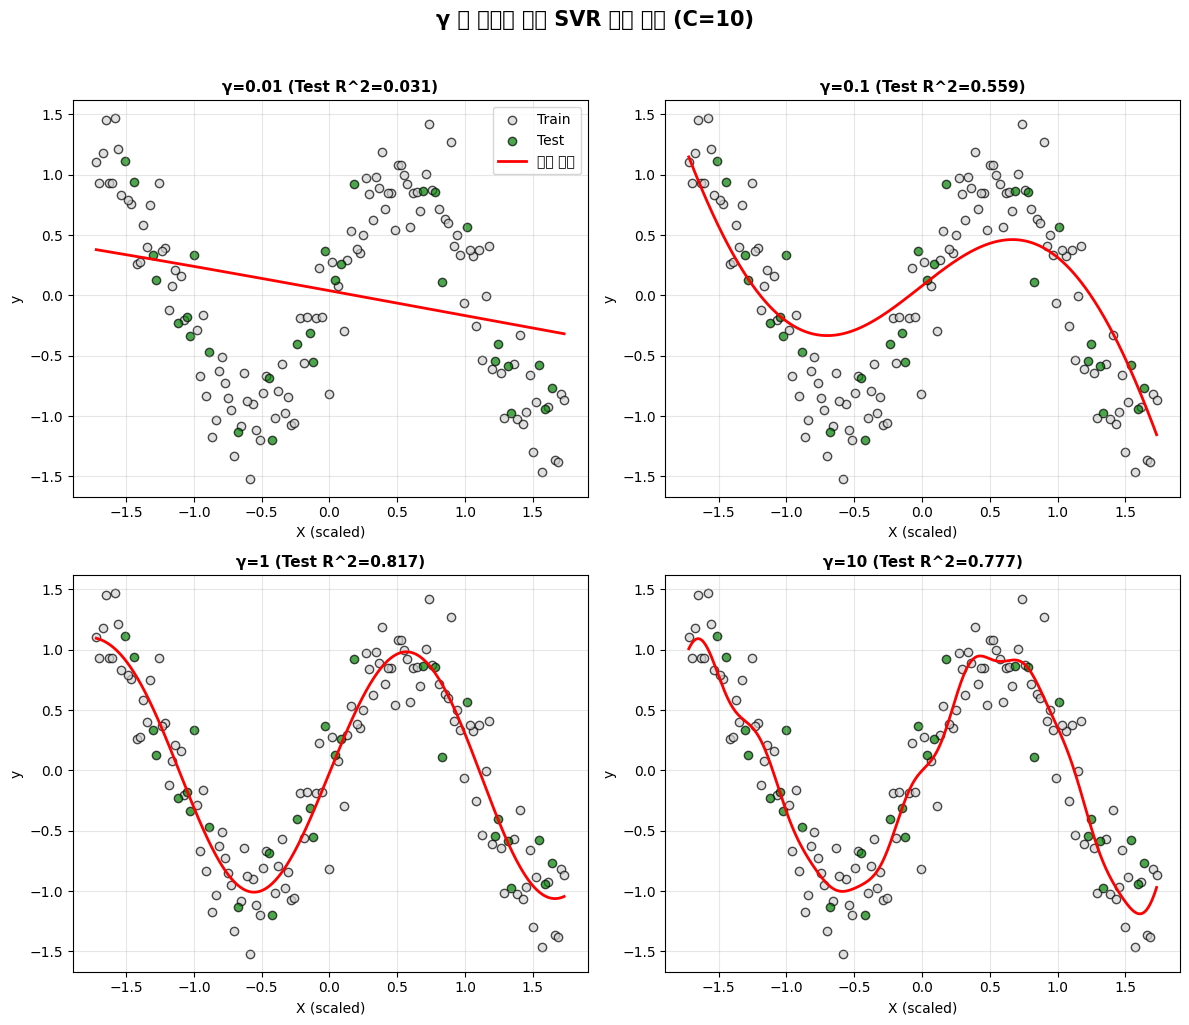


해석 가이드:
- γ 작음: RBF 커널의 영향 범위가 넓음 → 전체적으로 완만한 곡선
- γ 큼  : 한 점 근처에서만 크게 영향 → 곡선이 요철처럼 많이 휘어짐 (노이즈까지 따라감)


In [ ]:
# ------------------------------------------------------------
# 1-3. γ 변화에 따른 곡선 비교
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("1-3. γ 값 변화에 따른 SVR 곡선 비교")
print("=" * 70)

gamma_list = [0.01, 0.1, 1, 10]

plt.figure(figsize=(12, 10))

for i, gamma_val in enumerate(gamma_list, start=1):
    svr_g = SVR(
        kernel='rbf',
        C=10.0,
        epsilon=0.1,
        gamma=gamma_val
    )
    svr_g.fit(X_train_scaled, y_train)
    y_line_pred_g = svr_g.predict(X_line)

    y_pred_test_g = svr_g.predict(X_test_scaled)
    r2_g = r2_score(y_test, y_pred_test_g)

    plt.subplot(2, 2, i)
    plt.scatter(X_train_scaled, y_train, color='lightgray', edgecolor='k', alpha=0.7, label='Train')
    plt.scatter(X_test_scaled, y_test, color='green', edgecolor='k', alpha=0.7, label='Test')
    plt.plot(X_line, y_line_pred_g, color='red', linewidth=2, label='예측 곡선')
    plt.title(f"γ={gamma_val} (Test R^2={r2_g:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("X (scaled)")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend()

plt.suptitle("γ 값 변화에 따른 SVR 예측 곡선 (C=10)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("svr_toy_gamma_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n해석 가이드:")
print("- γ 작음: RBF 커널의 영향 범위가 넓음 → 전체적으로 완만한 곡선")
print("- γ 큼  : 한 점 근처에서만 크게 영향 → 곡선이 요철처럼 많이 휘어짐 (노이즈까지 따라감)")


1-4. ε 값 변화에 따른 SVR 곡선 및 ε-tube 비교


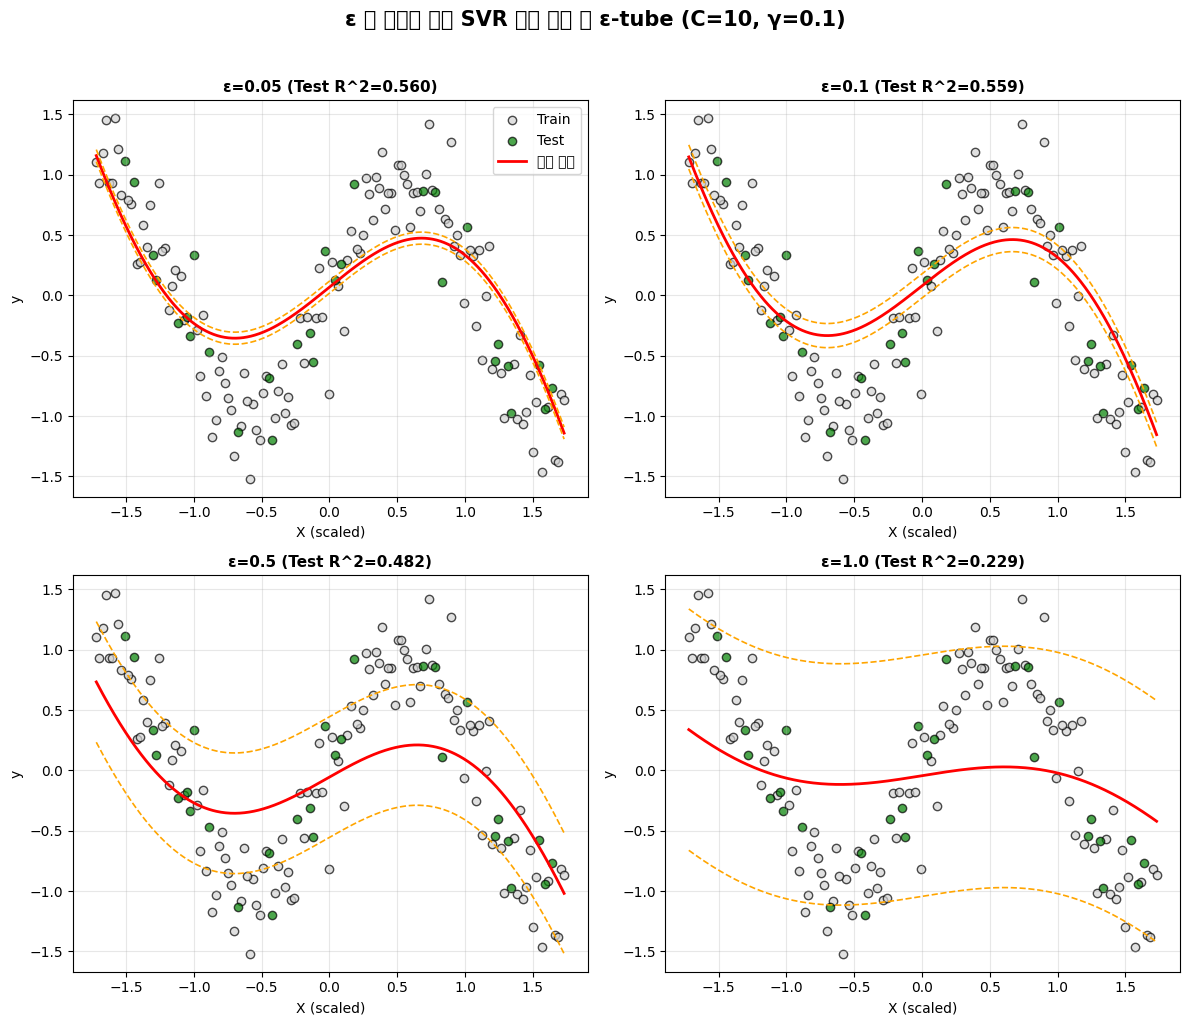


해석 가이드:
- ε 작음: ε-tube가 얇아짐 → 많은 점이 튜브 밖으로 나가서 페널티 → 더 빡빡하게 데이터에 맞춤
- ε 큼  : ε-tube가 넓어짐 → 튜브 안에 많은 점 포함, 오차로 안 봄 → 더 매끈한 곡선, underfitting 경향


In [ ]:
# ------------------------------------------------------------
# 1-4. ε 변화에 따른 곡선 비교
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("1-4. ε 값 변화에 따른 SVR 곡선 및 ε-tube 비교")
print("=" * 70)

epsilon_list = [0.05, 0.1, 0.5, 1.0]

plt.figure(figsize=(12, 10))

for i, eps_val in enumerate(epsilon_list, start=1):
    svr_e = SVR(
        kernel='rbf',
        C=10.0,
        epsilon=eps_val,
        gamma=0.1
    )
    svr_e.fit(X_train_scaled, y_train)
    y_line_pred_e = svr_e.predict(X_line)

    y_pred_test_e = svr_e.predict(X_test_scaled)
    r2_e = r2_score(y_test, y_pred_test_e)

    plt.subplot(2, 2, i)
    plt.scatter(X_train_scaled, y_train, color='lightgray', edgecolor='k', alpha=0.7, label='Train')
    plt.scatter(X_test_scaled, y_test, color='green', edgecolor='k', alpha=0.7, label='Test')
    plt.plot(X_line, y_line_pred_e, color='red', linewidth=2, label='예측 곡선')

    # ε-tube
    plt.plot(X_line, y_line_pred_e + eps_val, color='orange', linestyle='--', linewidth=1.2)
    plt.plot(X_line, y_line_pred_e - eps_val, color='orange', linestyle='--', linewidth=1.2)

    plt.title(f"ε={eps_val} (Test R^2={r2_e:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("X (scaled)")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend()

plt.suptitle("ε 값 변화에 따른 SVR 예측 곡선 및 ε-tube (C=10, γ=0.1)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("svr_toy_epsilon_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n해석 가이드:")
print("- ε 작음: ε-tube가 얇아짐 → 많은 점이 튜브 밖으로 나가서 페널티 → 더 빡빡하게 데이터에 맞춤")
print("- ε 큼  : ε-tube가 넓어짐 → 튜브 안에 많은 점 포함, 오차로 안 봄 → 더 매끈한 곡선, underfitting 경향")

In [ ]:

# ------------------------------------------------------------
# 2. 실제 데이터셋 (California Housing)으로 SVR 회귀
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. California Housing 데이터셋 - SVR 회귀")
print("=" * 70)

# 데이터 로드
california = fetch_california_housing()
X_cal = california.data
y_cal = california.target  # 집 가격 (단위: 100,000$)

feature_names = california.feature_names
print("데이터 shape:", X_cal.shape)
print("특성 이름:", feature_names)

# 연산 시간 줄이기 위해 일부 샘플링 (예: 5000개만 사용)
np.random.seed(42)
idx = np.random.choice(len(X_cal), size=5000, replace=False)
X_cal = X_cal[idx]
y_cal = y_cal[idx]

# Train/Test split
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train_cal.shape, "Test shape:", X_test_cal.shape)

# 스케일링 (X만)
scaler_cal = StandardScaler()
X_train_cal_scaled = scaler_cal.fit_transform(X_train_cal)
X_test_cal_scaled = scaler_cal.transform(X_test_cal)


2. California Housing 데이터셋 - SVR 회귀
데이터 shape: (20640, 8)
특성 이름: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train shape: (4000, 8) Test shape: (1000, 8)


In [ ]:
# ------------------------------------------------------------
# 2-1. 기본 SVR 모델
# ------------------------------------------------------------
print("\n[2-1] 기본 RBF SVR 모델 (GridSearch 전)")

base_svr_cal = SVR(
    kernel='rbf',
    C=10.0,
    epsilon=0.1,
    gamma='scale'
)
base_svr_cal.fit(X_train_cal_scaled, y_train_cal)

y_pred_train_cal = base_svr_cal.predict(X_train_cal_scaled)
y_pred_test_cal = base_svr_cal.predict(X_test_cal_scaled)

print("\nTrain 성능 (California Housing):")
metrics_train_cal = evaluate_regression(y_train_cal, y_pred_train_cal, prefix="Train")

print("\nTest 성능 (California Housing):")
metrics_test_cal = evaluate_regression(y_test_cal, y_pred_test_cal, prefix="Test")


[2-1] 기본 RBF SVR 모델 (GridSearch 전)

Train 성능 (California Housing):
[Train]
MSE :  0.2550
RMSE:  0.5050
MAE :  0.3304
R^2 :  0.8056

Test 성능 (California Housing):
[Test]
MSE :  0.3591
RMSE:  0.5992
MAE :  0.4016
R^2 :  0.7342


In [ ]:
# ------------------------------------------------------------
# 2-2. GridSearchCV로 하이퍼파라미터 튜닝
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2-2. GridSearchCV로 SVR 하이퍼파라미터 튜닝 (C, γ, ε)")
print("=" * 70)

param_grid_cal = {
    'C': [1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'epsilon': [0.05, 0.1, 0.2],
    'kernel': ['rbf']
}

print("GridSearch 파라미터:")
print(param_grid_cal)

grid_search_cal = GridSearchCV(
    SVR(),
    param_grid=param_grid_cal,
    cv=3,            # 회귀라 3-fold 정도로
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\nGridSearchCV 실행 중...")
grid_search_cal.fit(X_train_cal_scaled, y_train_cal)

print("\n최적 하이퍼파라미터:")
print(grid_search_cal.best_params_)
print(f"최적 CV MSE: {-grid_search_cal.best_score_:.4f}")

best_svr_cal = grid_search_cal.best_estimator_

# 최적 모델 평가
y_pred_train_best_cal = best_svr_cal.predict(X_train_cal_scaled)
y_pred_test_best_cal = best_svr_cal.predict(X_test_cal_scaled)

print("\n[기본 모델 vs 최적 모델 성능 비교 (California Housing)]")

metrics_best_train_cal = evaluate_regression(y_train_cal, y_pred_train_best_cal, prefix="Train - 최적")
metrics_best_test_cal = evaluate_regression(y_test_cal, y_pred_test_best_cal, prefix="Test  - 최적")

comparison_df = pd.DataFrame({
    '지표': ['MSE', 'RMSE', 'MAE', 'R^2'],
    '기본 모델 (Test)': [
        metrics_test_cal['mse'],
        metrics_test_cal['rmse'],
        metrics_test_cal['mae'],
        metrics_test_cal['r2']
    ],
    '최적 모델 (Test)': [
        metrics_best_test_cal['mse'],
        metrics_best_test_cal['rmse'],
        metrics_best_test_cal['mae'],
        metrics_best_test_cal['r2']
    ]
})

# R^2는 클수록 좋고, 나머지는 작을수록 좋음 → 개선율 해석에 주의
# 여기서는 단순하게 (최적 - 기본)/|기본| * 100 으로 표시
comparison_df['개선율(%)'] = (
    (comparison_df['최적 모델 (Test)'] - comparison_df['기본 모델 (Test)'])
    / np.abs(comparison_df['기본 모델 (Test)']) * 100
)

print("\n기본 vs 최적 모델 성능 비교표 (Test 기준):")
print(comparison_df.to_string(index=False))

print("\n=== SVM 회귀(SVR) 실습 전체 종료 ===")



2-2. GridSearchCV로 SVR 하이퍼파라미터 튜닝 (C, γ, ε)
GridSearch 파라미터:
{'C': [1, 10, 100], 'gamma': [0.01, 0.1, 1], 'epsilon': [0.05, 0.1, 0.2], 'kernel': ['rbf']}

GridSearchCV 실행 중...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

최적 하이퍼파라미터:
{'C': 10, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}
최적 CV MSE: 0.3283

[기본 모델 vs 최적 모델 성능 비교 (California Housing)]
[Train - 최적]
MSE :  0.2685
RMSE:  0.5182
MAE :  0.3499
R^2 :  0.7953
[Test  - 최적]
MSE :  0.3575
RMSE:  0.5979
MAE :  0.4034
R^2 :  0.7353

기본 vs 최적 모델 성능 비교표 (Test 기준):
  지표  기본 모델 (Test)  최적 모델 (Test)    개선율(%)
 MSE      0.359052      0.357476 -0.438903
RMSE      0.599209      0.597893 -0.219693
 MAE      0.401588      0.403415  0.454770
 R^2      0.734162      0.735329  0.158925

=== SVM 회귀(SVR) 실습 전체 종료 ===
